# Multi-asset, multi-crisis backtest grid

Run the eleven-test battery on every combination of five equity indices (S&P 500, NDX, FTSE, DAX, Nikkei) and five crisis windows (Dotcom, GFC, COVID-19, the 2022 inflation shock, SVB). Each cell fits AR(1)-GARCH(1,1)-t on a five-year in-sample window ending the day before the crisis OOS slice and reports backtest p-values.

In [1]:

import matplotlib.pyplot as plt
import yaml
from IPython.display import display

from esback.config import REPO_ROOT
from esback.multi_asset import (
    AssetSpec,
    PeriodSpec,
    reject_rate_per_period,
    reject_rate_per_test,
    run_grid,
)
from esback.viz import figures, style
from esback.viz.style import PALETTE

style.apply_rcparams()
ASSETS_FIG = REPO_ROOT / "assets" / "figures"
ASSETS_FIG.mkdir(parents=True, exist_ok=True)

cfg = yaml.safe_load((REPO_ROOT / "configs" / "multi_asset_crisis.yaml").read_text())
assets_specs = [AssetSpec(name=a["name"], ticker=a["ticker"]) for a in cfg["assets"]]
period_specs = [
    PeriodSpec(name=p["name"], oos_start=p["oos_start"], oos_end=p["oos_end"])
    for p in cfg["periods"]
]
[a.name for a in assets_specs], [p.name for p in period_specs]

(['SPX', 'NDX', 'FTSE', 'DAX', 'Nikkei'],
 ['Dotcom', 'GFC', 'COVID', 'Inflation_2022', 'SVB'])

## Run the grid

Twenty-five `(asset, period)` cells, eleven tests each: 275 p-values. The grid is cached in ``results/multi_asset/grid.parquet`` for fast re-execution.

In [2]:
RESULTS = REPO_ROOT / "results" / "multi_asset"
RESULTS.mkdir(parents=True, exist_ok=True)
grid_path = RESULTS / "grid.parquet"

if grid_path.exists():
    import pandas as pd

    grid = pd.read_parquet(grid_path)
    print(f"loaded cached grid ({len(grid)} rows)")
else:
    grid = run_grid(
        assets_specs,
        period_specs,
        data_start=cfg["data"]["start"],
        data_end=cfg["data"]["end"],
        in_sample_years=int(cfg["in_sample_years"]),
        alpha_es=float(cfg["backtest"]["alpha_es"]),
        alpha_var=float(cfg["backtest"]["alpha_var"]),
        m=int(cfg["backtest"]["m"]),
        n_sim=2_000,
        n_bootstrap=2_000,
    )
    grid.to_parquet(grid_path)
    print(f"computed and cached grid ({len(grid)} rows)")

grid.head()

loaded cached grid (275 rows)


,asset,period,test,statistic,p_value,alpha,decision,n_oos
0,SPX,Dotcom,U_ES,3.359879,0.000780,0.10,REJECT,689
1,SPX,Dotcom,C_ES(5),7.042519,0.217497,0.10,Fail to reject,689
2,SPX,Dotcom,U_VaR,2.193751,0.028253,0.05,REJECT,689
3,SPX,Dotcom,C_VaR(5),5.416841,0.367151,0.05,Fail to reject,689
4,SPX,Dotcom,Kupiec_POF,4.342209,0.037179,0.05,REJECT,689


## P-value heatmap

Each row is a backtest, each column an `(asset, period)` cell. Red shading = rejection at 5%, green = fail to reject.

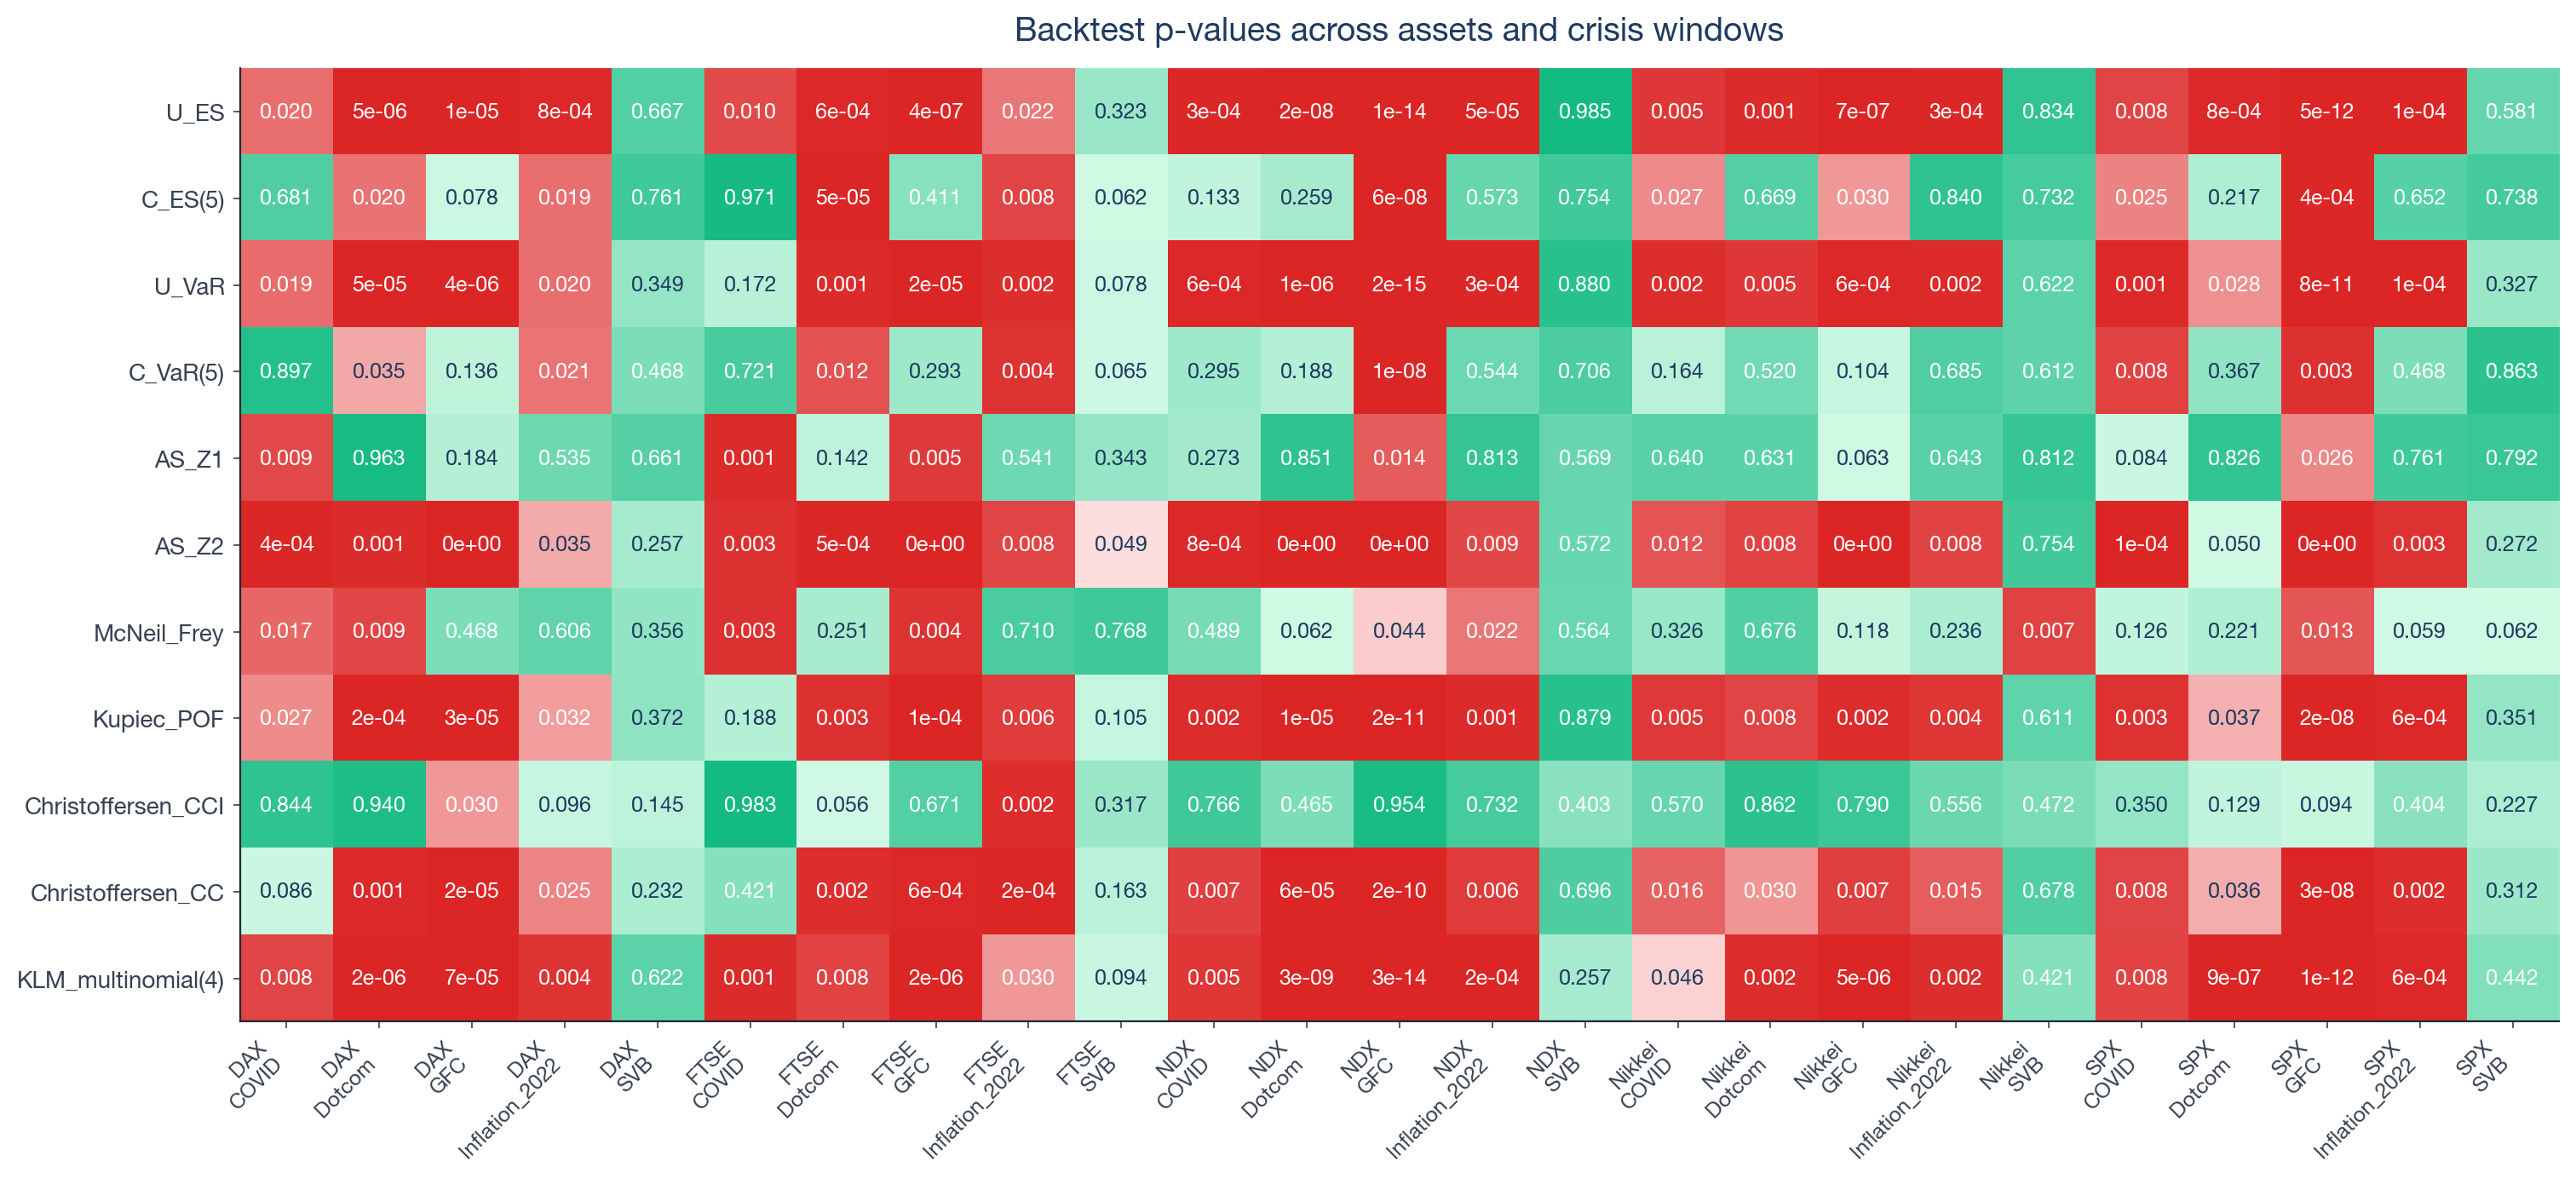

In [3]:
wide = grid.pivot_table(
    index="test", columns=["asset", "period"], values="p_value", aggfunc="first"
)
wide.columns = [f"{a}\n{p}" for a, p in wide.columns]
test_order = [
    "U_ES",
    "C_ES(5)",
    "MU_ES",
    "MC_ES(5)",
    "U_VaR",
    "C_VaR(5)",
    "AS_Z1",
    "AS_Z2",
    "McNeil_Frey",
    "Kupiec_POF",
    "Christoffersen_CCI",
    "Christoffersen_CC",
    "KLM_multinomial(4)",
]
wide = wide.reindex([t for t in test_order if t in wide.index])

fig = figures.plot_p_value_heatmap(
    wide,
    title="Backtest p-values across assets and crisis windows",
    save_to=ASSETS_FIG / "02_battery_heatmap.png",
)
plt.show()

## Rejection rate per test

Across the 25 cells, what share rejects at the 5% level?

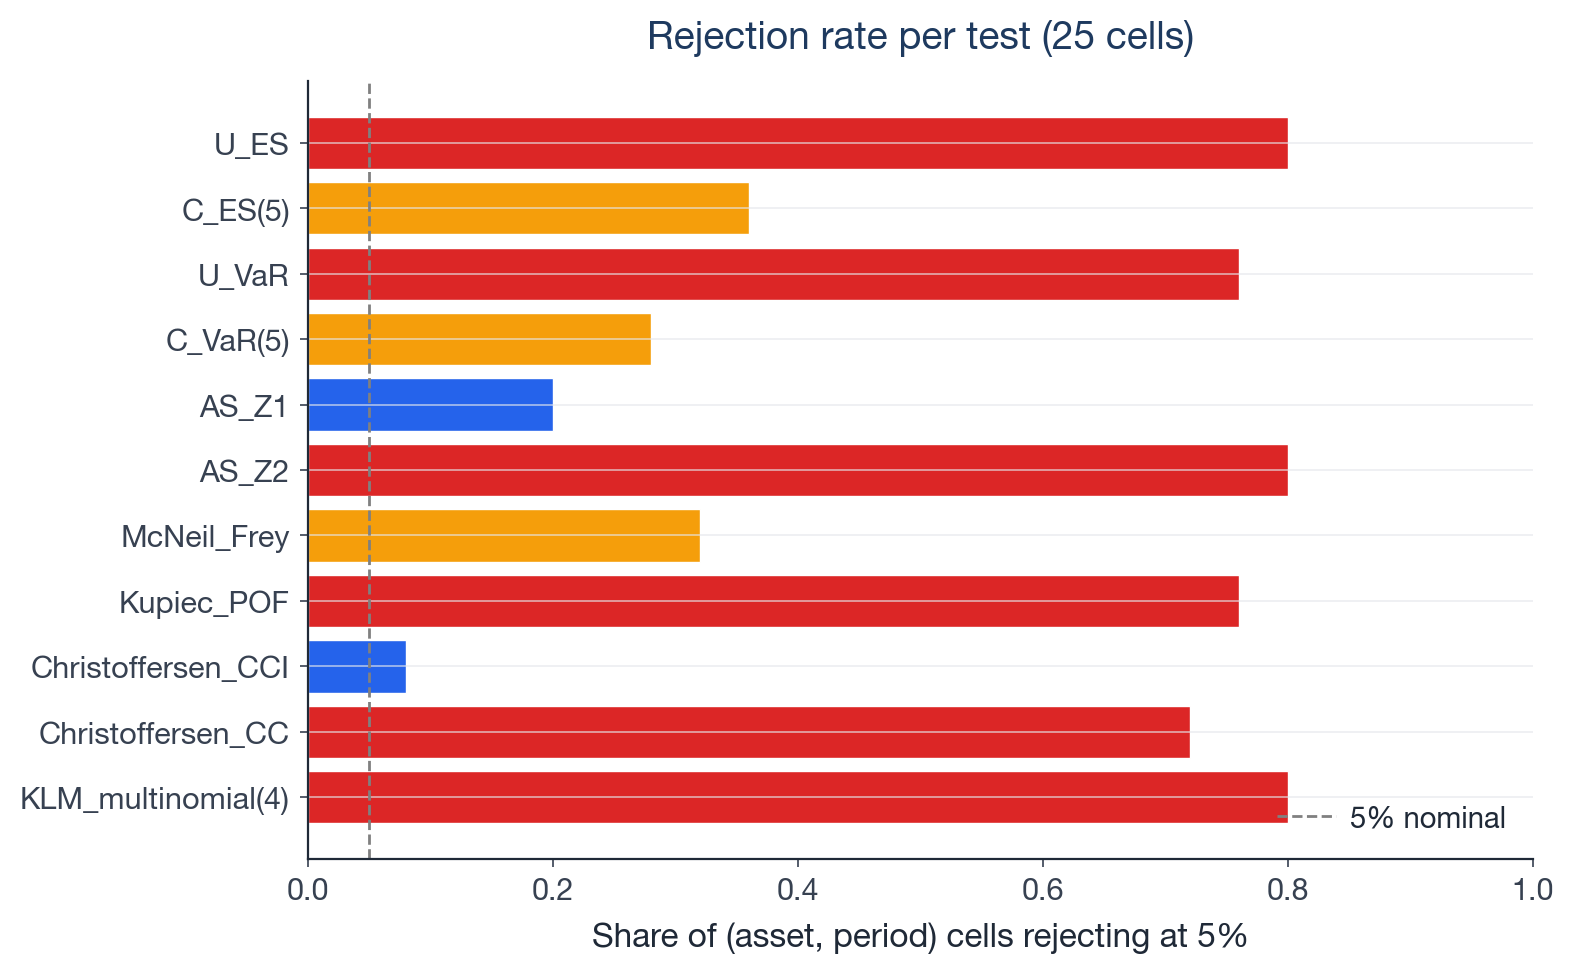

In [4]:
rate = reject_rate_per_test(grid, level=0.05).reindex(
    [t for t in test_order if t in reject_rate_per_test(grid).index]
)

fig, ax = plt.subplots(figsize=(8, 5))
colors = [
    PALETTE["red"] if r > 0.5 else PALETTE["orange"] if r > 0.2 else PALETTE["blue"]
    for r in rate["reject_rate"]
]
ax.barh(rate.index, rate["reject_rate"], color=colors, edgecolor="white")
ax.axvline(0.05, color="gray", linestyle="--", linewidth=1, label="5% nominal")
ax.set_xlabel("Share of (asset, period) cells rejecting at 5%")
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.legend(loc="lower right")
ax.set_title("Rejection rate per test (25 cells)")
fig.tight_layout()
fig.savefig(ASSETS_FIG / "02_reject_rate_per_test.png", bbox_inches="tight", dpi=200)
plt.show()

## Rejection rate by period

Heatmap of share of assets rejecting per ``(test, period)``.

In [5]:
per_period = reject_rate_per_period(grid, level=0.05).reindex(
    [t for t in test_order if t in reject_rate_per_period(grid).index]
)
display(per_period.round(2))

period,COVID,Dotcom,GFC,Inflation_2022,SVB
test,,,,,
U_ES,1.0,1.0,1.0,1.0,0.0
C_ES(5),0.4,0.4,0.6,0.4,0.0
U_VaR,0.8,1.0,1.0,1.0,0.0
C_VaR(5),0.2,0.4,0.4,0.4,0.0
AS_Z1,0.4,0.0,0.6,0.0,0.0
AS_Z2,1.0,0.8,1.0,1.0,0.2
McNeil_Frey,0.4,0.2,0.6,0.2,0.2
Kupiec_POF,0.8,1.0,1.0,1.0,0.0
Christoffersen_CCI,0.0,0.0,0.2,0.2,0.0


## Discussion

**Five-by-five grid.** All 25 `(asset, period)` cells estimate without numerical issues; the grid totals 275 statistics over `5 assets × 5 periods × 11 tests`. The robust statistics `MU_ES` and `MC_ES(5)` live outside `multi_asset.run_grid`, which has neither the `fit` nor the `returns_all` series required to differentiate them numerically.

**Unconditional coverage vs independence.** Across the four non-SVB windows (20 cells per test), `Christoffersen_CCI` rejects 0/5 on Dotcom, 1/5 on GFC, 0/5 on COVID, 1/5 on Inflation_2022 — just 2/20. By contrast `Christoffersen_CC` rejects 18/20 and `Kupiec_POF` rejects 19/20. Since `LR_CC = LR_UC + LR_IND` (chi-squared with 2 dof = chi-squared with 1 dof + chi-squared with 1 dof), and `LR_UC` is precisely the Kupiec component, the gap between `Christoffersen_CC` and `Christoffersen_CCI` is carried almost entirely by `LR_UC`: the marginal inflation in the number of violations, not the clustering pattern. The day-to-day independence test detects a misspecification on at most 1/5 assets per period.

**ES test hierarchy outside SVB.** `KLM_multinomial(4)` and `U_ES` reject 20/20 (every cell). `AS_Z2` reaches 19/20, `Kupiec_POF` 19/20, `U_VaR` 19/20, `Christoffersen_CC` 18/20. `C_ES(5)` and `C_VaR(5)` — the Box-Pierce statistics on cumulative violations — sit in the middle at 9/20 and 7/20. `AS_Z1` (5/20) and `McNeil_Frey` (7/20) lag behind; both depend heavily on the number of effective violations in the OOS window, and several cells have too few violations to give those statistics teeth.

**Most stressed regimes.** GFC and COVID-19 are the windows where unconditional coverage is massively violated: `Kupiec_POF` reaches 100% (GFC) and 80% (COVID), `KLM_multinomial(4)` reaches 100% on both, `AS_Z2` reaches 100% on both. The independence-only component stays low (20% on GFC, 0% on COVID): on these windows the excess violations are *numerous* without being *consecutively clustered* in the sense of the two-state Markov chain tested by `Christoffersen_CCI`.

**SVB is the quiet outlier.** Across all 11 tests, SVB triggers only 2 rejections (1 from `AS_Z2`, 1 from `McNeil_Frey`) out of 55 cells. The seven-month 2023-03 → 2023-09 window saw a sharp regional-bank shock but limited index-level volatility, so the AR(1)-GARCH(1,1)-t baseline scales its envelope correctly. SVB is a useful negative control: a "stress" window where the model does not in fact mis-specify ES on equity indices, illustrating that crisis labels and ES-mis-specification do not always coincide.